In [10]:
import pandas as pd
import sqlalchemy as sa
import urllib
from sqlalchemy import create_engine
from sqlalchemy import text
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from bs4 import BeautifulSoup as bs
import requests
import re
import numpy as np
import adjustText

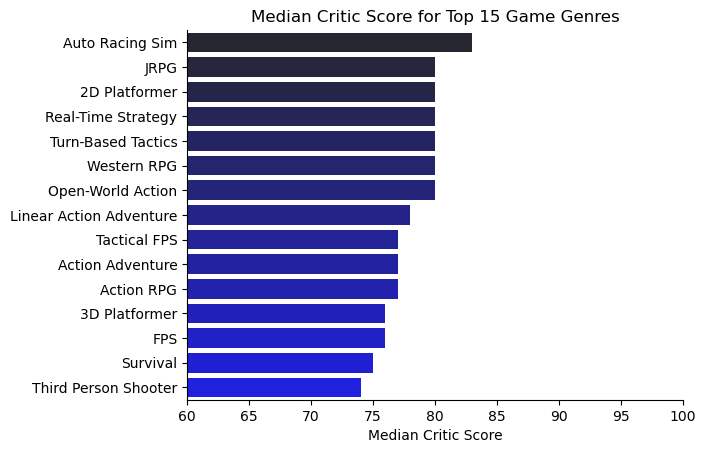

In [18]:
df_games = pd.read_csv(r'C:\Users\bryan\OneDrive\Desktop\Python_Projects\Metacritic_Analysis\raw_data\metacritic_data.csv')
df_games = df_games.drop_duplicates()
df_games


df_games['score'] = df_games['score'].astype(int)
df_games['user_score']=df_games['user_score'].astype(float)
df_genre_sort=df_games.groupby('genre').agg(
count=('title', 'count'),
median_score= ('score', 'median'),
user_score_median = ('user_score', 'median')
).sort_values(by='count', ascending=False).head(15)
df_genre_sort= df_genre_sort.sort_values(by='median_score', ascending=False)
df_genre_sort
sns.barplot(df_genre_sort, x='median_score', y ='genre', hue = 'genre', palette='dark:b', legend=False)
ax=plt.gca()
plt.title('Median Critic Score for Top 15 Game Genres')
plt.ylabel('')
plt.xlabel('Median Critic Score')
sns.despine()
plt.xlim(60, 100)
plt.show()


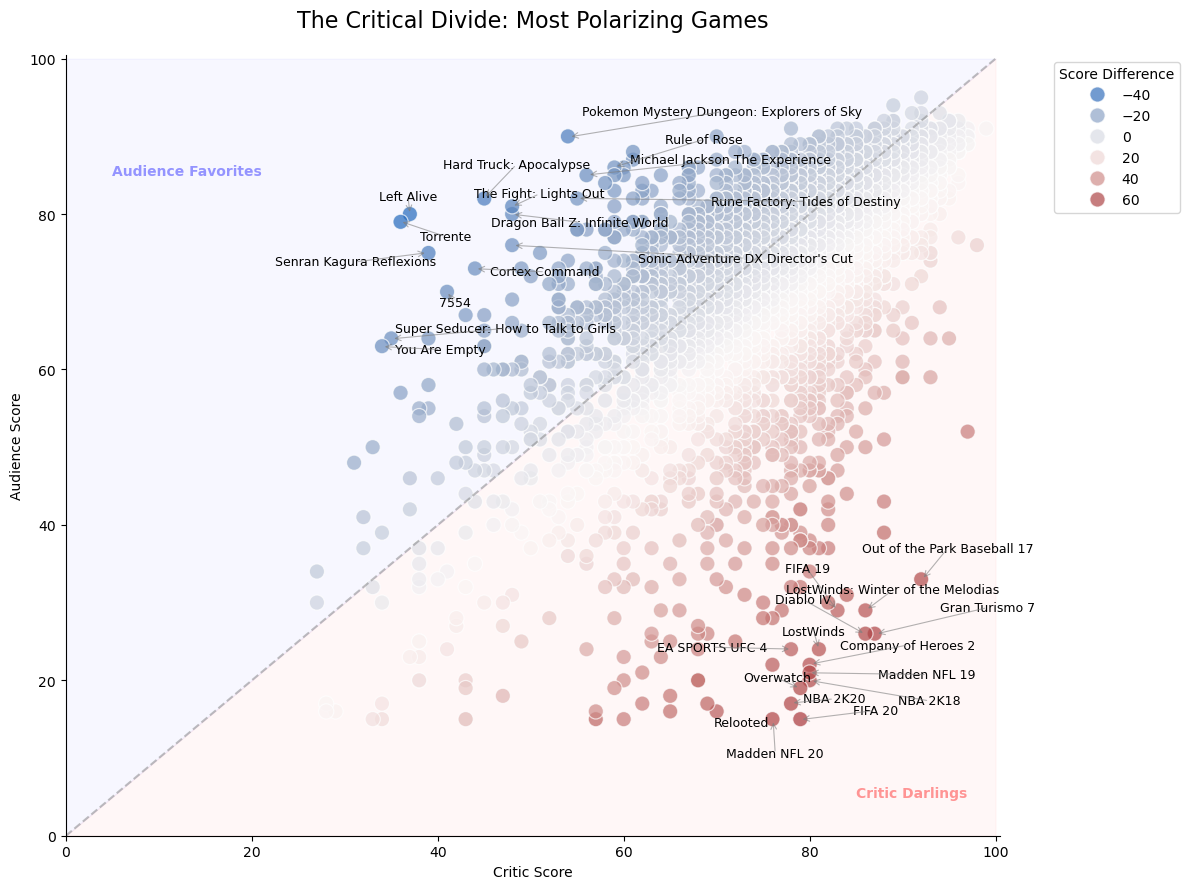

In [12]:
df_score_comparison = df_games.copy()
df_score_comparison = df_score_comparison.drop_duplicates(subset=('title'))
df_score_comparison['audience_score_x10'] = df_score_comparison['user_score'] * 10
df_score_comparison['score_diff'] = df_score_comparison['score'] - df_score_comparison['audience_score_x10']
# 1. Sort: Highest numbers (Critic Darlings) at the top
df_sorted = df_score_comparison.sort_values('score_diff', ascending=False)

# 2. Grab the Extremes correctly
# Top of the list = highest positive difference (Critics loved it more)
critic_darlings = df_sorted[df_sorted['score_diff'] >= 3].head(15)

# Bottom of the list = highest negative difference (Audience loved it more)
audience_favs = df_sorted[df_sorted['score_diff'] <= -2].tail(15)

# 3. Combine
label_df = pd.concat([critic_darlings, audience_favs])
label_df
plt.figure(figsize=(12, 9))

# 2. Shaded Background Zones (Adds immediate context)
plt.fill_between([0, 100], [0, 100], 100, color='blue', alpha=0.03) 
plt.fill_between([0, 100], 0, [0, 100], color='red', alpha=0.03)
plt.text(5, 85, "Audience Favorites", color='blue', alpha=0.4, fontweight='bold')
plt.text(85, 5, "Critic Darlings", color='red', alpha=0.4, fontweight='bold')

# 3. Main Scatter Plot
sns.scatterplot(
    data=df_score_comparison, 
    x='score', y='audience_score_x10', 
    hue='score_diff', palette='vlag', 
    s=120, alpha=0.7, edgecolor='w'
)

# 4. The Labeling Logic (with Jitter)
texts = []
for i, row in label_df.iterrows():
    # Adding tiny jitter (0.1) prevents labels from starting on the exact same pixel
    x_pos = row['score'] + np.random.uniform(-0.1, 0.1)
    y_pos = row['audience_score_x10'] + np.random.uniform(-0.1, 0.1)
    
    texts.append(plt.text(x_pos, y_pos, row['title'], fontsize=9, fontweight='medium'))

# 5. Perfecting the Placement
adjustText.adjust_text(
    texts, 
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8, alpha=0.6),
    expand_points=(2, 2),
    force_text=(0.5, 1.0)
)

# Formatting
plt.plot([0, 100], [0, 100], ls="--", c=".5", alpha=0.5) # Equality line
ax = plt.gca()
plt.xlim(0, 100.5) # Extra 0.5 gives room for labels on the right edge
plt.ylim(0, 100.5)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Score Difference')
plt.title('The Critical Divide: Most Polarizing Games', fontsize=16, pad=20)
sns.despine()
plt.ylabel('Audience Score')
plt.xlabel('Critic Score')
plt.tight_layout()
plt.show()

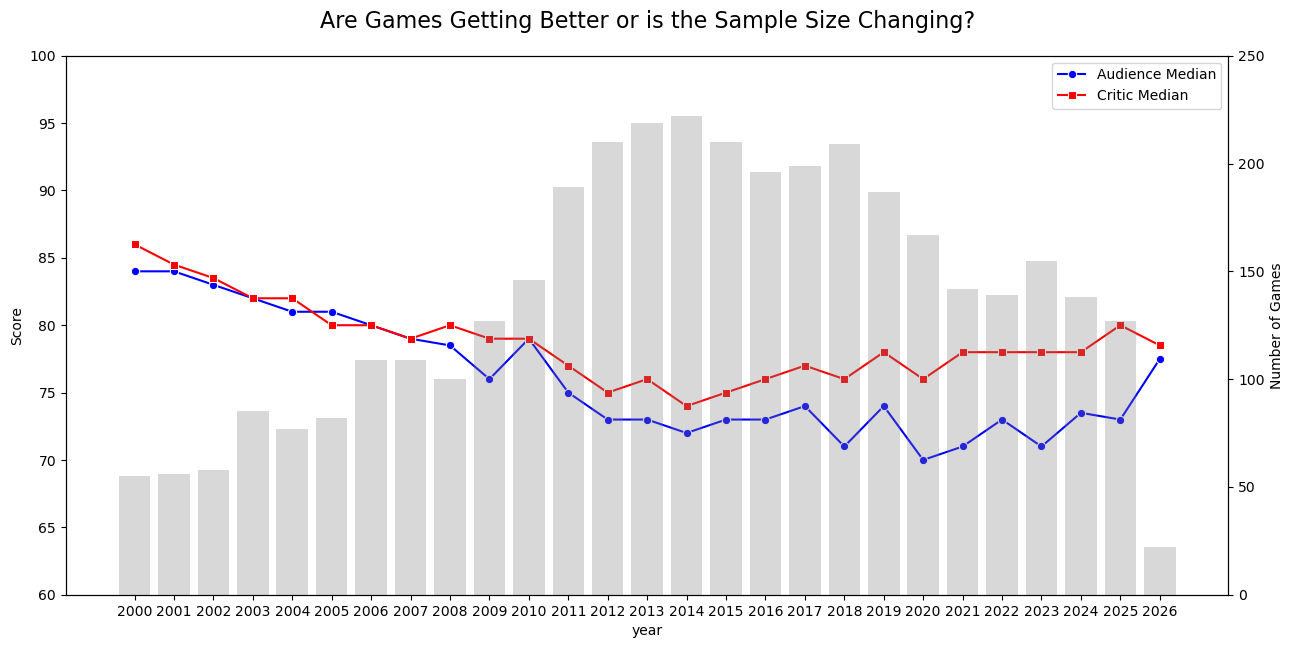

In [13]:
line_plot = df_games.copy()
line_plot['audience_score_x10'] = line_plot['user_score'] * 10
line_plot=line_plot[line_plot['year'] > 1999]
line_plot= line_plot.groupby('year').agg(
    avg_critic_score= ('score', 'median'),
   avg_audience_score =('audience_score_x10','median'),
  game_count = ('title', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot the scores
sns.lineplot(data=line_plot, x='year', y='avg_audience_score', ax=ax1, label='Audience Median', color='blue', marker='o')
sns.lineplot(data=line_plot, x='year', y='avg_critic_score', ax=ax1, label='Critic Median', color='red', marker='s')

# Create a second Y-axis for the game count
ax2 = ax1.twinx()
ax2.bar(line_plot['year'], line_plot['game_count'], alpha=0.3, color='gray', label='Number of Games')

# Formatting
ax1.set_ylabel('Score')
ax2.set_ylabel('Number of Games')

plt.title('Are Games Getting Better or is the Sample Size Changing?', fontsize=16, pad=20)
plt.xticks(line_plot['year'], rotation=45)
ax2.set_ylim(0, 250)
ax1.set_ylim(60, 100)

plt.show()

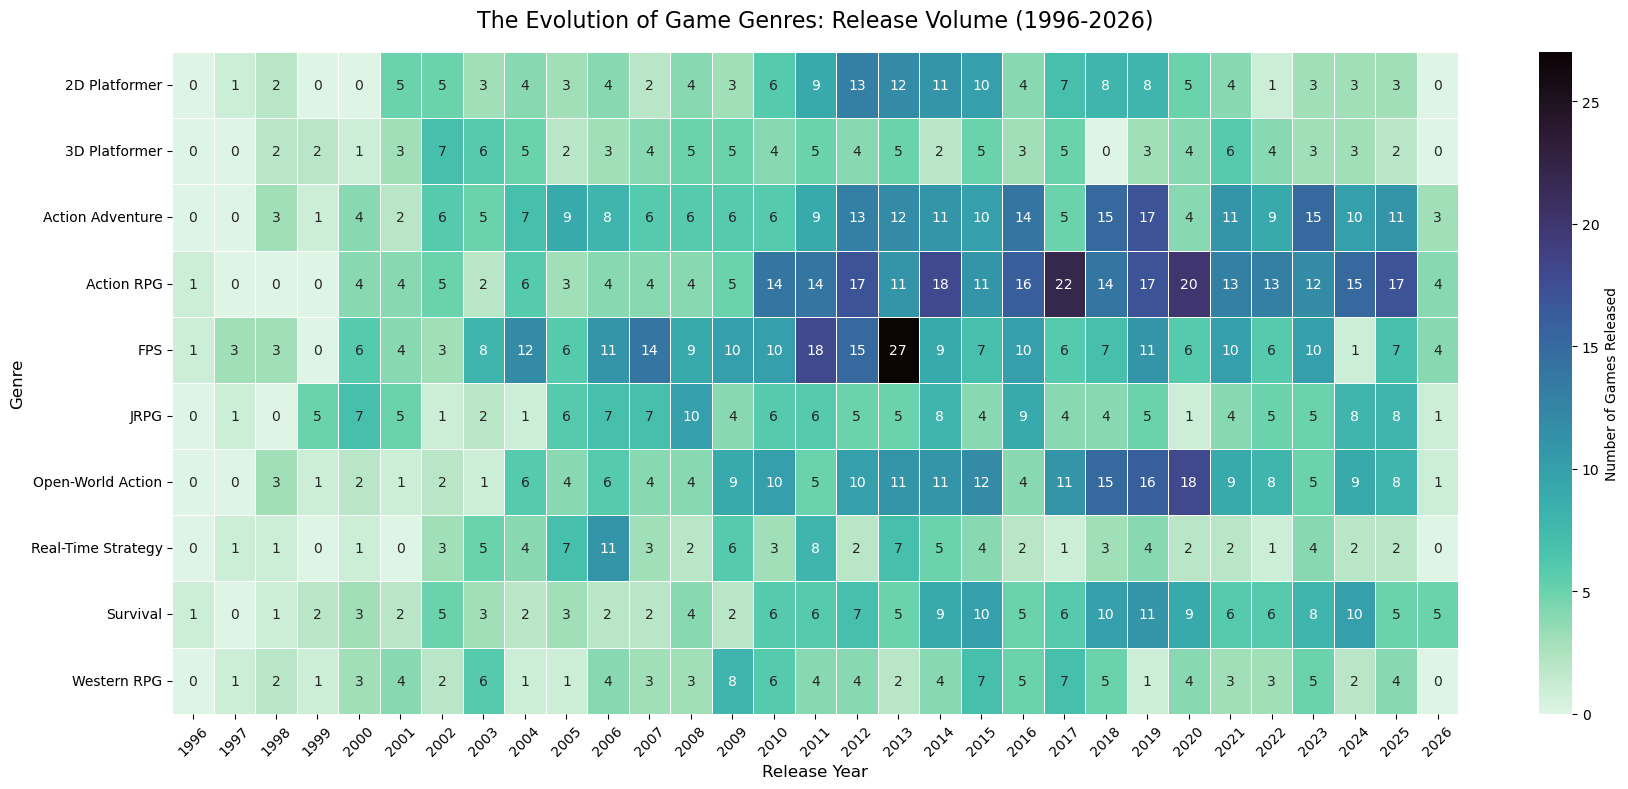

In [14]:
# 1. Find the top 10 genres by total count
top_10_genres = df_games['genre'].value_counts().nlargest(10).index

# 2. Filter the original dataframe
df_top_genres = df_games[df_games['genre'].isin(top_10_genres)]
genre_stacked=df_top_genres.pivot_table(index='genre', columns = 'year', values='title', aggfunc = 'count').fillna(0)
plt.figure(figsize=(18, 8))

# The heatmap "Magic"
sns.heatmap(
    genre_stacked, 
 
    annot=True,              # 1. Put the actual numbers inside the boxes
    fmt='g',                 # 2. Keep the numbers as integers
    cmap='mako_r',           # 3. Yellow (Low) to Blue (High) is very intuitive
    linewidths=.5,           # 4. Tiny lines between boxes make it look "crisp"
    cbar_kws={'label': 'Number of Games Released'}
)

# 5. Clean up the labels
plt.title('The Evolution of Game Genres: Release Volume (1996-2026)', fontsize=16, pad=18)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

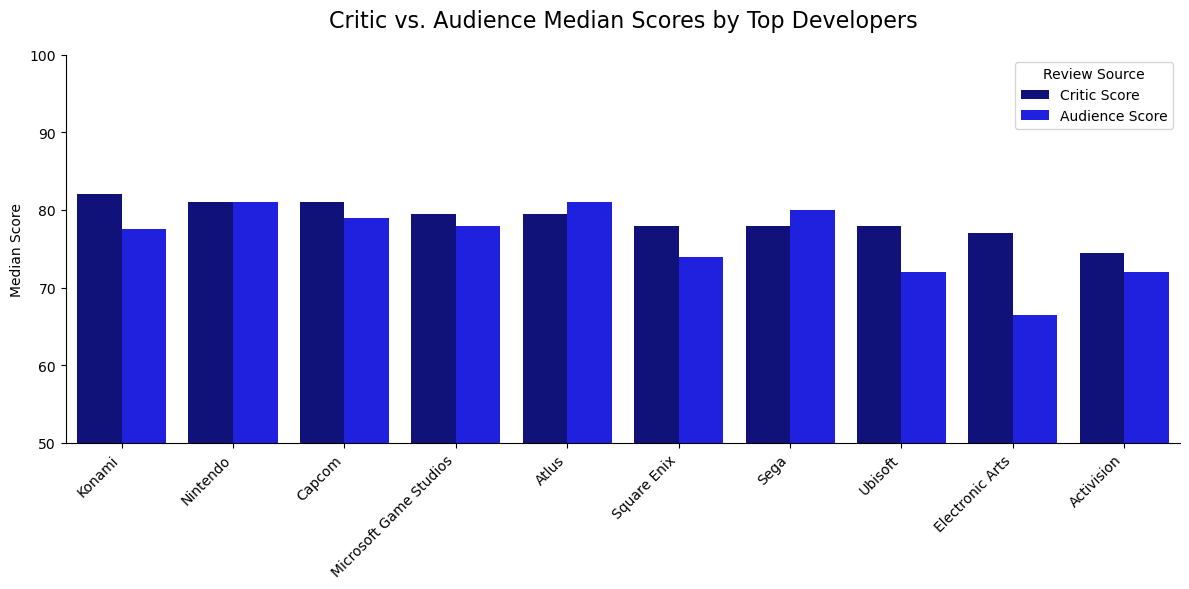

In [15]:
dev_bar_plot = df_games[df_games['dev'] !='N/A'].copy()
dev_bar_plot['user_score_x10'] = dev_bar_plot['user_score'] *10
dev_stats = dev_bar_plot.groupby('dev').agg(
    critic_median=('score', 'median'),
    audience_median=('user_score_x10', 'median'),
    game_count=('title', 'count')).sort_values(by = 'game_count', ascending=False).head(10).reset_index()

dev_stats=dev_stats.sort_values('critic_median', ascending=False)

# 3. "Melt" the data: This turns two columns into one 'Score' column and one 'Type' column
dev_melted = dev_stats.melt(id_vars='dev', 
                            value_vars=['critic_median', 'audience_median'], 
                            var_name='Score Type', 
                            value_name='Score Value')

# 4. Plot
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(data=dev_melted, x='dev', y='Score Value', hue='Score Type', 
            palette={'critic_median': 'darkblue', 'audience_median': 'blue'})


# Formatting
plt.ylim(50, 100)  # Zoom in to see the differences clearly
plt.xticks(rotation=45, ha='right')
plt.title('Critic vs. Audience Median Scores by Top Developers', fontsize=16, pad=20)

plt.xlabel('')
handles, labels = ax1.get_legend_handles_labels()


ax1.legend(handles, ['Critic Score', 'Audience Score'], 
           title='Review Source', 
           loc='upper right', 
           frameon=True)
plt.ylabel('Median Score')
sns.despine()
plt.tight_layout()
plt.show()


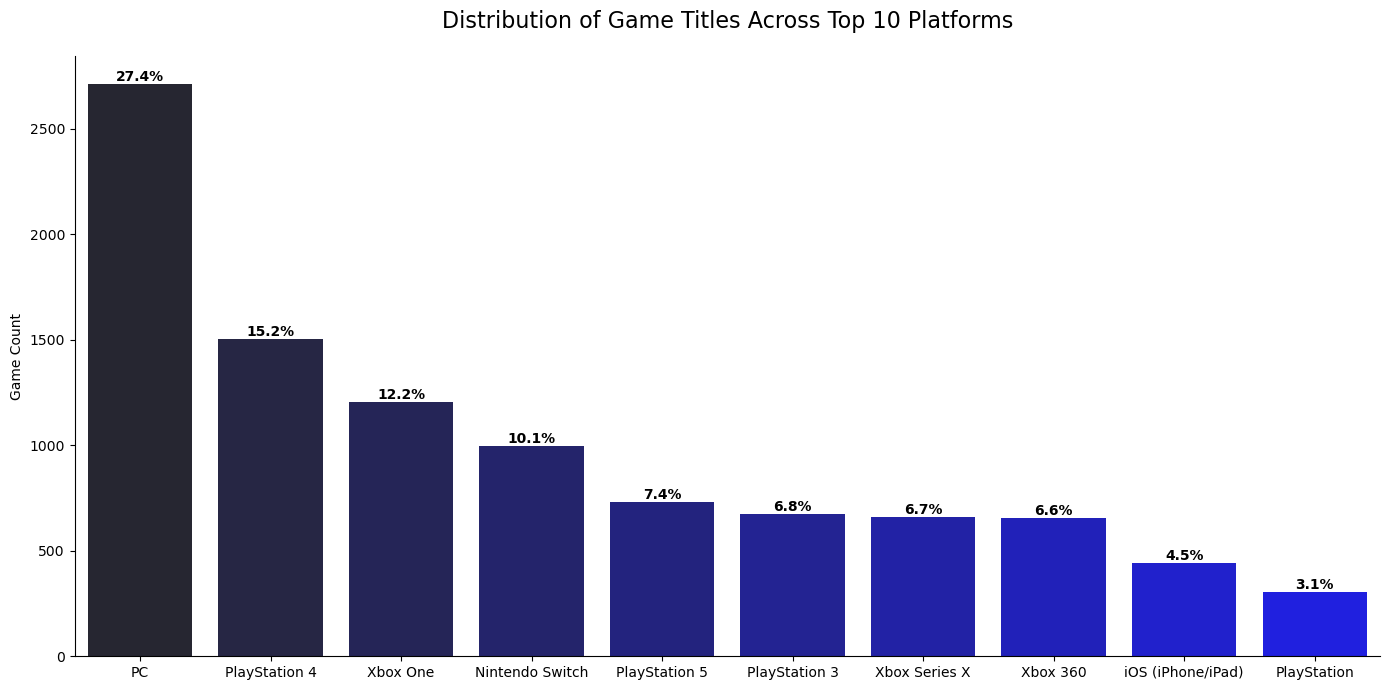

In [16]:
df_platform = df_games.copy()
df_platform['platform_list'] = df_platform['platform'].str.split(', ')
df_platform = df_platform.explode('platform_list')
df_platform_plot=df_platform.groupby('platform_list').size().sort_values(ascending=False).head(10).reset_index(name='platform_count')
df_platform_plot['platform_percent'] = 100* df_platform_plot['platform_count']/393

plt.figure(figsize=(14, 7))
ax=sns.barplot(df_platform_plot, x='platform_list', y ='platform_count', hue='platform_list', palette='dark:b')

total = df_platform_plot['platform_count'].sum()
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%' # Calculate % on the fly
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('')
plt.ylabel('Game Count')
plt.title('Distribution of Game Titles Across Top 10 Platforms', fontsize=16, pad=20)
sns.despine()
plt.tight_layout()
plt.show()


C:\Users\bryan\AppData\Local\Temp\ipykernel_6328\1648010475.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df_rating, x='score_dif', y = 'rating', order = rating_order, palette='vlag')


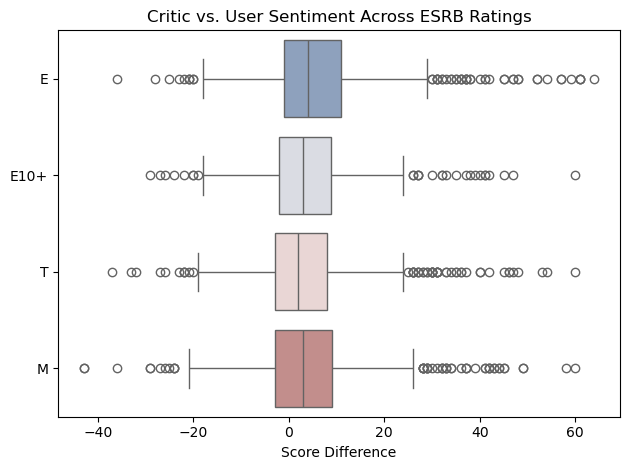

In [17]:
df_rating = df_games.copy()
df_rating = df_rating.dropna(subset='rating')

df_rating['audience_score_x10'] = df_rating['user_score'] *10
df_rating = df_rating.dropna(subset='rating')
df_rating['score_dif'] = df_rating['score'] - df_rating['audience_score_x10']
df_rating['rating'].unique()
rating_order = ['E', 'E10+', 'T', 'M']
sns.boxplot(df_rating, x='score_dif', y = 'rating', order = rating_order, palette='vlag')
plt.title('Critic vs. User Sentiment Across ESRB Ratings')
plt.ylabel('')
plt.xlabel('Score Difference')
plt.tight_layout()
plt.show()
